# Train RakForest CNN on Forest Sound

เทรน CNN ขนาดเล็กด้วย PyTorch จาก `processed/forest_sound_16k_5s` โดยอ่าน label จากชื่อโฟลเดอร์, สร้าง Mel-Spectrogram ตอนรัน training/evaluation และรองรับ Apple MPS พร้อม fallback เป็น CPU

> Notebook นี้อ่านข้อมูลจาก raw/processed เท่านั้น ไม่แก้ไขไฟล์ dataset ใด ๆ และเขียนเฉพาะ checkpoint ไปที่ `models/`

หาก environment ยังไม่มี dependencies ให้ติดตั้งก่อน: `pip install torch torchaudio soundfile pandas matplotlib seaborn`

In [9]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf
import torch
import torch.nn as nn
import torchaudio
from torch.utils.data import DataLoader, Dataset

sns.set_theme(style="whitegrid")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for candidate in candidates:
        if (candidate / "processed" / "forest_sound_16k_5s").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("ไม่พบ processed/forest_sound_16k_5s")

PROJECT_ROOT = find_project_root()
DATASET_ROOT = PROJECT_ROOT / "processed" / "forest_sound_16k_5s"
MODEL_DIR = PROJECT_ROOT / "models"
BEST_MODEL_PATH = MODEL_DIR / "rakforest_cnn_best.pt"
SAMPLE_RATE = 16_000
CLIP_SECONDS = 5
NUM_SAMPLES = SAMPLE_RATE * CLIP_SECONDS
BATCH_SIZE = 32
NUM_EPOCHS = 15

if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Dataset: {DATASET_ROOT}")
print(f"Device: {DEVICE}")
print(f"Best model: {BEST_MODEL_PATH}")

Dataset: /Users/guidegiegg/งาน/โปรเจคเล็กๆ/PrePair_Sound/processed/forest_sound_16k_5s
Device: mps
Best model: /Users/guidegiegg/งาน/โปรเจคเล็กๆ/PrePair_Sound/models/rakforest_cnn_best.pt


## 1. สร้าง label และอ่านไฟล์จาก `train/val/test`

In [10]:
AUDIO_EXTENSIONS = {".wav", ".wave", ".flac", ".aiff", ".aif"}
SPLITS = ["train", "val", "test"]

# Labels are derived from the train folder and checked against val/test.
class_names = sorted(p.name for p in (DATASET_ROOT / "train").iterdir() if p.is_dir())
if not class_names:
    raise ValueError("ไม่พบ class folders ใน train")
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

for split in SPLITS:
    split_dir = DATASET_ROOT / split
    found = sorted(p.name for p in split_dir.iterdir() if p.is_dir())
    if found != class_names:
        raise ValueError(f"คลาสใน {split} ไม่ตรงกับ train: {found}")

class_names, class_to_idx

(['fire', 'logging', 'natural sound', 'poaching'],
 {'fire': 0, 'logging': 1, 'natural sound': 2, 'poaching': 3})

In [11]:
class AudioFolderDataset(Dataset):
    """อ่านคลิปเสียง fixed-length; Mel-Spectrogram จะสร้างภายหลังใน train/eval loop"""
    def __init__(self, root, class_to_idx, sample_rate=SAMPLE_RATE, num_samples=NUM_SAMPLES):
        self.root = Path(root)
        self.class_to_idx = class_to_idx
        self.sample_rate = sample_rate
        self.num_samples = num_samples
        self.items = []
        for class_name, label in class_to_idx.items():
            class_dir = self.root / class_name
            for path in sorted(class_dir.rglob("*")):
                if path.is_file() and path.suffix.lower() in AUDIO_EXTENSIONS:
                    self.items.append((path, label))
        if not self.items:
            raise ValueError(f"ไม่พบไฟล์เสียงใน {self.root}")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, index):
        path, label = self.items[index]
        waveform, sr = sf.read(path, dtype="float32", always_2d=True)
        waveform = torch.from_numpy(waveform.mean(axis=1))
        if sr != self.sample_rate:
            raise ValueError(f"{path} มี sample rate {sr}, คาดหวัง {self.sample_rate}")
        if waveform.numel() < self.num_samples:
            waveform = torch.nn.functional.pad(waveform, (0, self.num_samples - waveform.numel()))
        else:
            waveform = waveform[:self.num_samples]
        return waveform, torch.tensor(label, dtype=torch.long)

datasets = {split: AudioFolderDataset(DATASET_ROOT / split, class_to_idx) for split in SPLITS}
loaders = {
    split: DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=(split == "train"),
                      num_workers=0, pin_memory=False)
    for split, dataset in datasets.items()
}

count_table = pd.DataFrame({
    split: pd.Series(np.bincount([label for _, label in datasets[split].items], minlength=len(class_names)), index=class_names)
    for split in SPLITS
})
display(count_table)
print({split: len(dataset) for split, dataset in datasets.items()})

,train,val,test
fire,989,221,220
logging,318,68,69
natural sound,954,204,205
poaching,426,91,91


{'train': 2687, 'val': 584, 'test': 585}


## 2. Class weights และ Mel-Spectrogram แบบ on-the-fly

In [12]:
train_counts = count_table["train"].to_numpy(dtype=np.float32)
class_weights = train_counts.sum() / (len(class_names) * np.maximum(train_counts, 1))
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
display(pd.DataFrame({"class": class_names, "train_count": train_counts.astype(int), "weight": class_weights.cpu().numpy()}))

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=1024,
    hop_length=256,
    n_mels=64,
    f_min=20,
    f_max=SAMPLE_RATE // 2,
).to(DEVICE)

def to_log_mel(waveforms):
    # This transform runs here during every training/evaluation batch.
    mel = mel_transform(waveforms.to(DEVICE))
    mel = torch.log(mel.clamp_min(1e-6))
    mel = (mel - mel.mean(dim=(-2, -1), keepdim=True)) / (mel.std(dim=(-2, -1), keepdim=True) + 1e-6)
    # torchaudio returns (batch, mel, time); CNN expects (batch, channel, mel, time).
    return mel.unsqueeze(1)

example_waveforms, _ = next(iter(loaders["train"]))
example_mel = to_log_mel(example_waveforms[:2])
print(f"Waveform batch: {tuple(example_waveforms.shape)} -> Mel batch: {tuple(example_mel.shape)}")

,class,train_count,weight
0,fire,989,0.679221
1,logging,318,2.112421
2,natural sound,954,0.704140
3,poaching,426,1.576878


Waveform batch: (32, 80000) -> Mel batch: (2, 1, 64, 313)


## 3. CNN ขนาดเล็ก

In [13]:
class SmallAudioCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.30), nn.Linear(64, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))

model = SmallAudioCNN(len(class_names)).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

SmallAudioCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=64, out_features=4, bias=True

## 4. Train 15 epochs และบันทึก validation-best checkpoint

In [14]:
def run_epoch(loader, training):
    model.train(training)
    total_loss = 0.0
    total_correct = 0
    total_items = 0
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for waveforms, labels in loader:
            waveforms, labels = waveforms.to(DEVICE), labels.to(DEVICE)
            inputs = to_log_mel(waveforms)
            logits = model(inputs)
            loss = criterion(logits, labels)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_items += labels.size(0)
    return total_loss / total_items, total_correct / total_items

MODEL_DIR.mkdir(parents=True, exist_ok=True)
history = []
best_val_accuracy = -1.0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_accuracy = run_epoch(loaders["train"], training=True)
    val_loss, val_accuracy = run_epoch(loaders["val"], training=False)
    history.append({
        "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
        "train_accuracy": train_accuracy, "val_accuracy": val_accuracy,
    })
    marker = ""
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "sample_rate": SAMPLE_RATE,
            "clip_seconds": CLIP_SECONDS,
            "n_mels": 64,
            "best_val_accuracy": best_val_accuracy,
            "epoch": epoch,
        }, BEST_MODEL_PATH)
        marker = "  * saved best"
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | train loss {train_loss:.4f}, acc {train_accuracy:.3f} | val loss {val_loss:.4f}, acc {val_accuracy:.3f}{marker}")

history_df = pd.DataFrame(history)
print(f"Best validation accuracy: {best_val_accuracy:.3f}")
print(f"Saved checkpoint: {BEST_MODEL_PATH}")

Epoch 01/15 | train loss 0.8864, acc 0.698 | val loss 0.6685, acc 0.800  * saved best
Epoch 02/15 | train loss 0.6295, acc 0.786 | val loss 0.5881, acc 0.759
Epoch 03/15 | train loss 0.5724, acc 0.801 | val loss 1.0211, acc 0.435
Epoch 04/15 | train loss 0.5250, acc 0.814 | val loss 0.4722, acc 0.839  * saved best
Epoch 05/15 | train loss 0.4892, acc 0.836 | val loss 0.4079, acc 0.848  * saved best
Epoch 06/15 | train loss 0.4786, acc 0.831 | val loss 0.4433, acc 0.841
Epoch 07/15 | train loss 0.4579, acc 0.829 | val loss 0.4457, acc 0.830
Epoch 08/15 | train loss 0.4283, acc 0.833 | val loss 0.4348, acc 0.846
Epoch 09/15 | train loss 0.4353, acc 0.854 | val loss 0.4640, acc 0.822
Epoch 10/15 | train loss 0.4147, acc 0.846 | val loss 0.4770, acc 0.822
Epoch 11/15 | train loss 0.4146, acc 0.842 | val loss 0.4652, acc 0.815
Epoch 12/15 | train loss 0.3976, acc 0.853 | val loss 0.3539, acc 0.873  * saved best
Epoch 13/15 | train loss 0.4061, acc 0.852 | val loss 0.3890, acc 0.866
Epoch 14

## 5. กราฟ train/validation loss และ accuracy

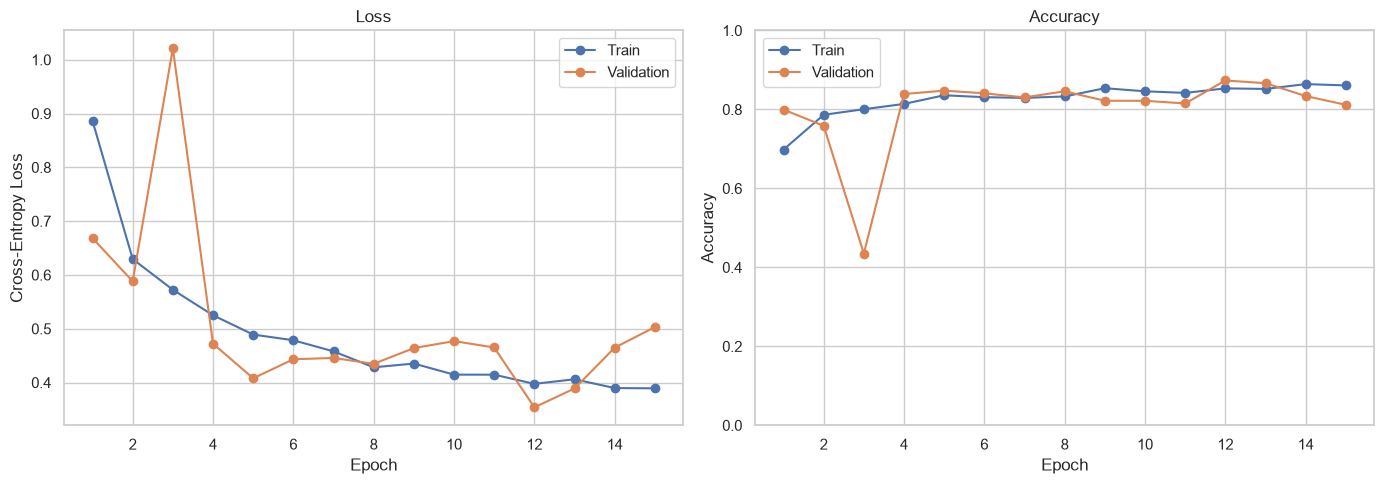

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_df.epoch, history_df.train_loss, marker="o", label="Train")
axes[0].plot(history_df.epoch, history_df.val_loss, marker="o", label="Validation")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="Cross-Entropy Loss")
axes[0].legend()
axes[1].plot(history_df.epoch, history_df.train_accuracy, marker="o", label="Train")
axes[1].plot(history_df.epoch, history_df.val_accuracy, marker="o", label="Validation")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. ประเมินบน test set ด้วยโมเดลที่ดีที่สุด

In [16]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
test_loss, test_accuracy = run_epoch(loaders["test"], training=False)
print(f"Best epoch: {checkpoint['epoch']}")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.3f}")
print(f"Checkpoint exists: {BEST_MODEL_PATH.exists()} ({BEST_MODEL_PATH.stat().st_size / 1024**2:.2f} MB)")

Best epoch: 12
Test loss: 0.3782
Test accuracy: 0.877
Checkpoint exists: True (0.10 MB)
